# Определение перспективного тарифа для телеком-компании

Цели и исследования:

- Определить какой тарифный план приносит наибольший доход для компании

Так же необходимо ответить на следующие вопросы:

- Сколько звонков делает каждый пользователь в месяц
- Сколько тратит минут каждый пользователь в месяц
- Сколько сообщений отправляет каждый пользователь в месяц
- Какой объем интернет трафика использует каждый пользователь в месяц
- Какая выручка с каждого пользователя в месяц
- Определить сколько минут, сообщений и трафика требуется пользователям для каждого тарифа в месяц

Проверить следующие гипотезы:

- Средняя выручка пользователей между тарифами **Ультра** и **Смарт** различаются
- Средняя выручка пользователей в Москве отличаются от средней выручки пользователей из других регионов


## Импорт библиотек и данных

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
users_data = pd.read_csv('../data/processed/user_month.csv')
tariffs = pd.read_csv('../data/processed/tariffs.csv')

In [23]:
users_data.head()

,user_id,month,minutes_per_month,calls_cnt_per_month,session_cnt_per_month,gb_used_per_month,used_msg_per_month,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,5,159.0,22.0,5.0,3.0,22.0,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1000,6,172.0,43.0,49.0,23.0,60.0,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
2,1000,7,340.0,47.0,29.0,14.0,75.0,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
3,1000,8,408.0,52.0,29.0,14.0,81.0,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
4,1000,9,466.0,58.0,27.0,15.0,57.0,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra


## Исследовательский анализ данных

### Поведение пользователей по объему использования услуг

Сравним тарифы по минутам, сообщениям, трафику и выручке

In [24]:
user_month = users_data.merge(
  tariffs, left_on='tariff', right_on='tariff_name', how='left'
)

user_month['min_extra'] = (user_month['minutes_per_month'] - user_month['minutes_included']).clip(lower=0)
user_month['sms_extra'] = (user_month['used_msg_per_month'] - user_month['messages_included']).clip(lower=0)
user_month['gb_extra'] = (user_month['gb_used_per_month'] - user_month['gb_per_month_included']).clip(lower=0)

user_month['revenue'] = (
  user_month['rub_monthly_fee']
  + user_month['min_extra'] * user_month['rub_per_minute']
  + user_month['sms_extra'] * user_month['rub_per_message']
  + user_month['gb_extra'] * user_month['rub_per_gb']
)

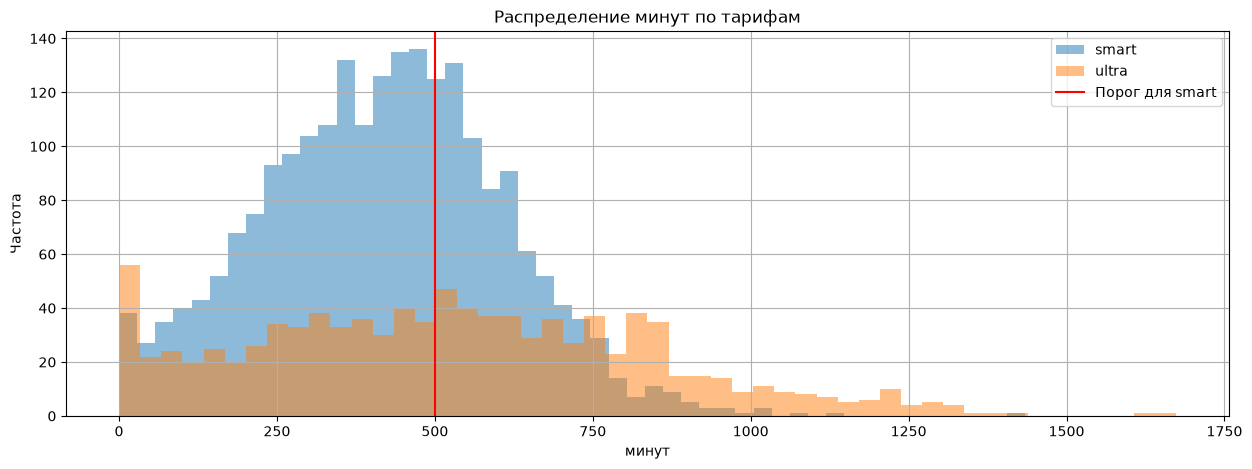

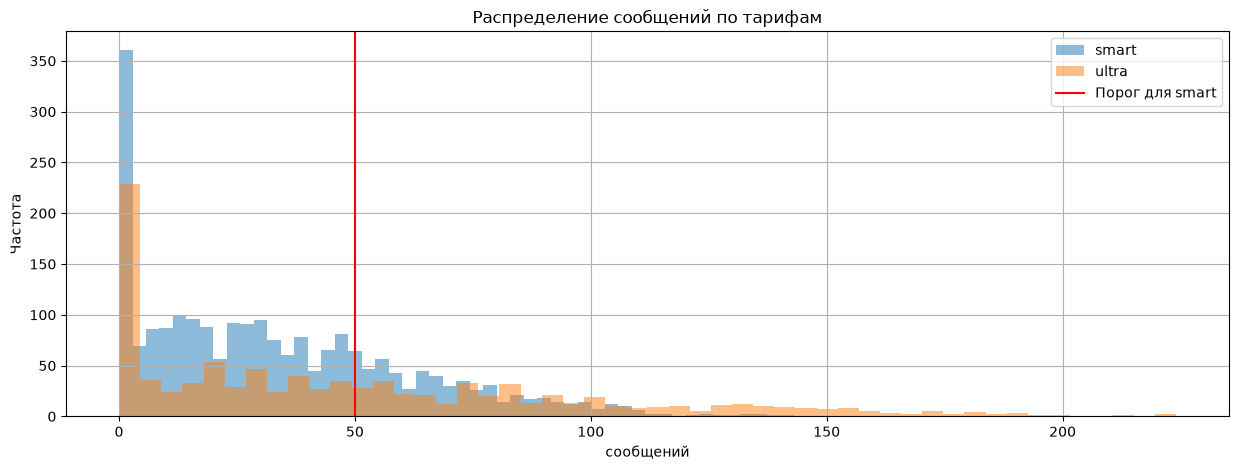

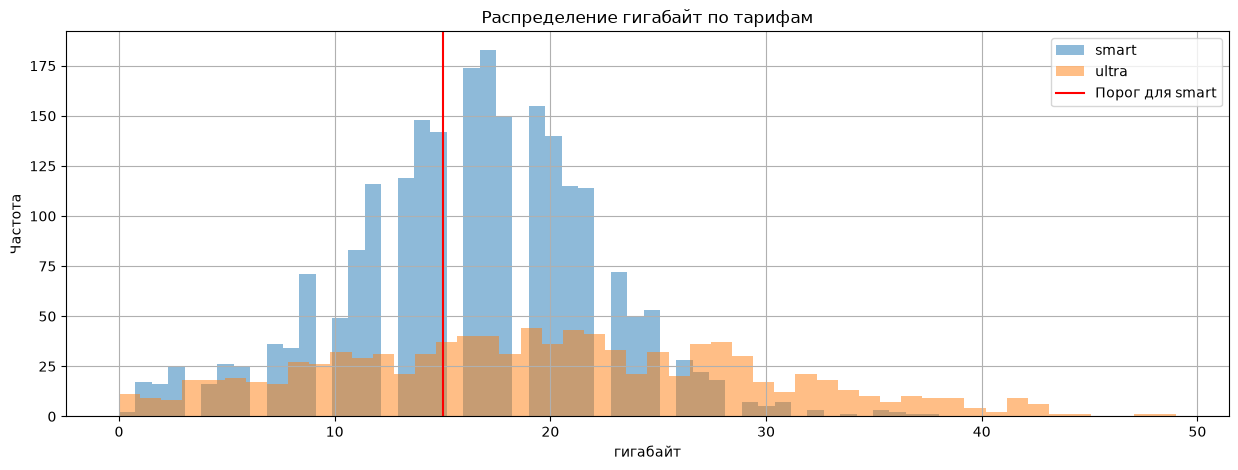

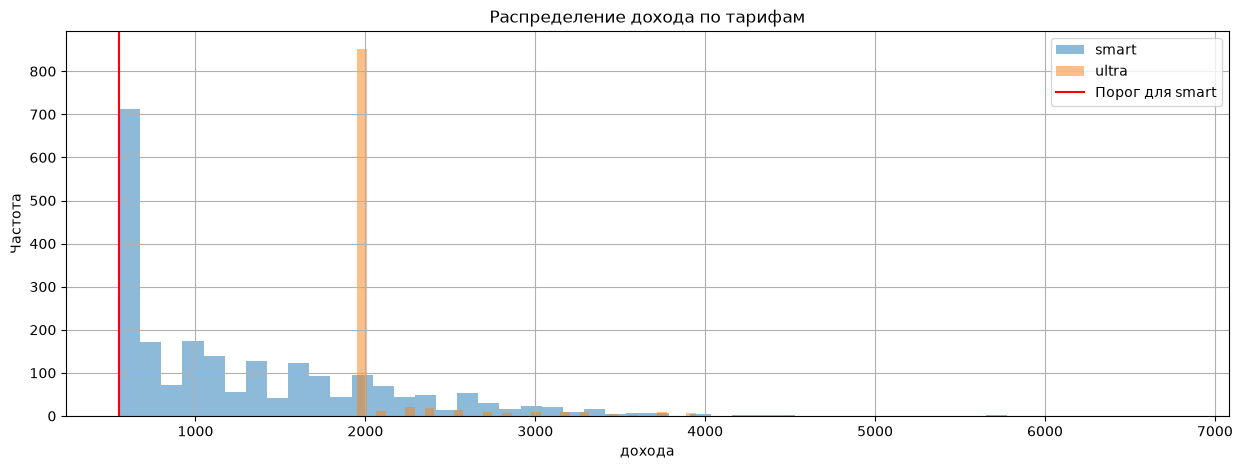

In [25]:
smart_users = user_month.query('tariff == "smart"')
ultra_users = user_month.query('tariff == "ultra"')

for parameter in ['minutes_per_month', 'used_msg_per_month', 'gb_used_per_month', 'revenue']:
  display(
    user_month.groupby('tariff')
              .agg({parameter: ['mean', 'median', 'var', 'std']})
              .style.format('{:.2f}')
  )

  if parameter == 'minutes_per_month':
    par_name = 'минут'
    treshold = tariffs.loc[tariffs['tariff_name'] == 'smart', 'minutes_included'].item()
  elif parameter == 'used_msg_per_month':
    par_name = 'сообщений'
    treshold = tariffs.loc[tariffs['tariff_name'] == 'smart', 'messages_included'].item()
  elif parameter == 'gb_used_per_month':
    par_name = 'гигабайт'
    treshold = tariffs.loc[tariffs['tariff_name'] == 'smart', 'gb_per_month_included'].item()
  elif parameter == 'revenue':
    par_name = 'дохода'
    treshold = tariffs.loc[tariffs['tariff_name'] == 'smart', 'rub_monthly_fee'].item()

  plt.figure(figsize=(15, 5))
  plt.hist(smart_users[parameter], label='smart', alpha=0.5, bins=50)
  plt.hist(ultra_users[parameter], label='ultra', alpha=0.5, bins=50)
  plt.axvline(x=treshold, label='Порог для smart', color='r')
  plt.xlabel(par_name)
  plt.ylabel('Частота')
  plt.title(f'Распределение {par_name} по тарифам')
  plt.grid()
  plt.legend()
  plt.show()

#### Вывод
Использование минут:

- На тарифе `smart` основная масса месяцев около 400–450 минут, на `ultra` разброс шире и больше месяцев почти без звонков
- Пользователи `smart` чаще выходят за лимит 500 минут, пользователи `ultra` до половины пакета (3000) почти не добираются
- Среднее: `smart` — 418 минут, `ultra` — 527 минут

Использование сообщений:

- На обоих тарифах распределение скошено вправо: много месяцев без SMS или с малым числом
- На `ultra` лимит 1000 почти не используется, на `smart` часть месяцев выходит за 50 сообщений, но чаще укладываются в пакет или не пишут вовсе
- Среднее: `smart` — 33 сообщения, `ultra` — 49 сообщений

Использование интернет-трафика:

- На обоих тарифах основная масса месяцев в середине диапазона, хвосты меньше
- Пользователи `smart` часто не укладываются в 15 ГБ и докупают трафик. На `ultra` сверх 30 ГБ тоже бывает, но реже
- Среднее: `smart` — 16 ГБ, `ultra` — 19 ГБ

Доход с пользователей:

- У `ultra` основная масса на абонентской плате 1950 ₽, редкие доплаты. У `smart` часто платят больше 550 ₽ и иногда больше, чем типичный месяц на `ultra`
- Среднее в месяц: `smart` — 1290 ₽, `ultra` — 2070 ₽
- Пользователи `smart` чаще выходят за лимит 500 минут, пользователи `ultra` до половины пакета (3000) почти не добираются
- Среднее: `smart` — 418 минут, `ultra` — 527 минут

### Исследование поведения пользователей по месяцам

Суммы по всей выборке за календарный месяц, не среднее на человека. Столбики stacked: тарифы один на другом. Рост к декабрю — в том числе набор клиентов в течение 2018.

tariff,smart,ultra
month,,
1,34,9
2,58,24
3,77,37
4,112,55
5,141,67
6,164,84
7,201,91
8,235,107
9,260,115


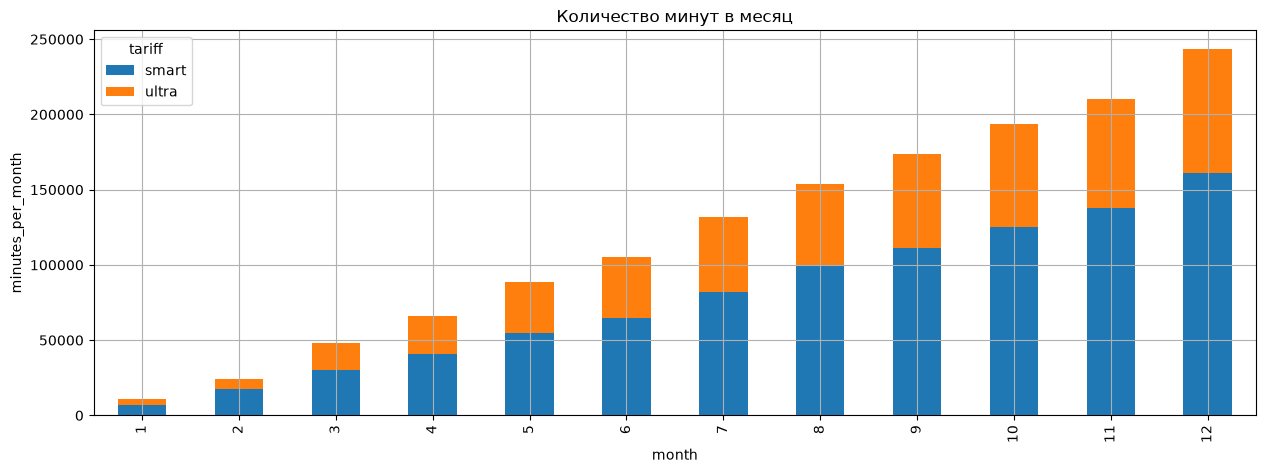

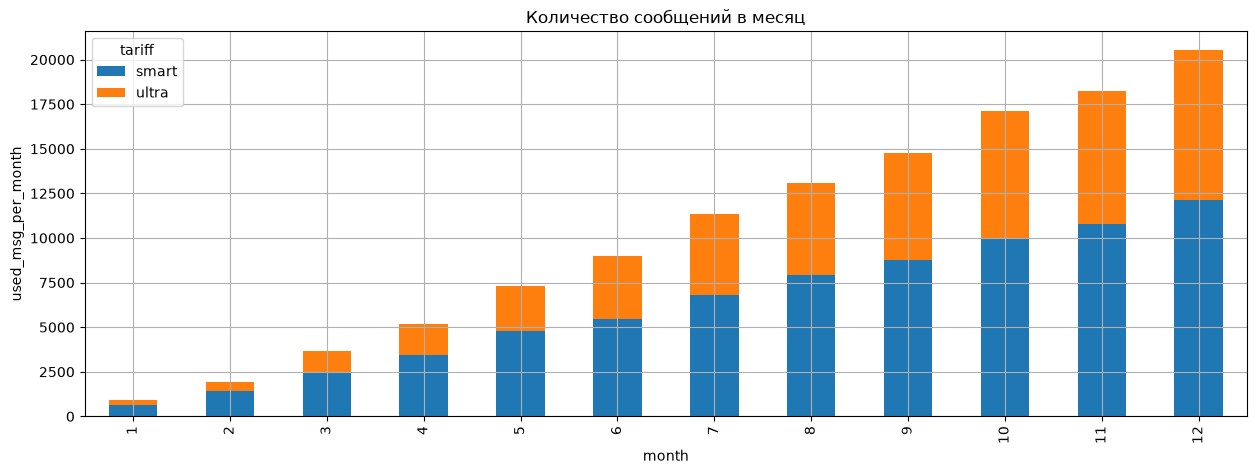

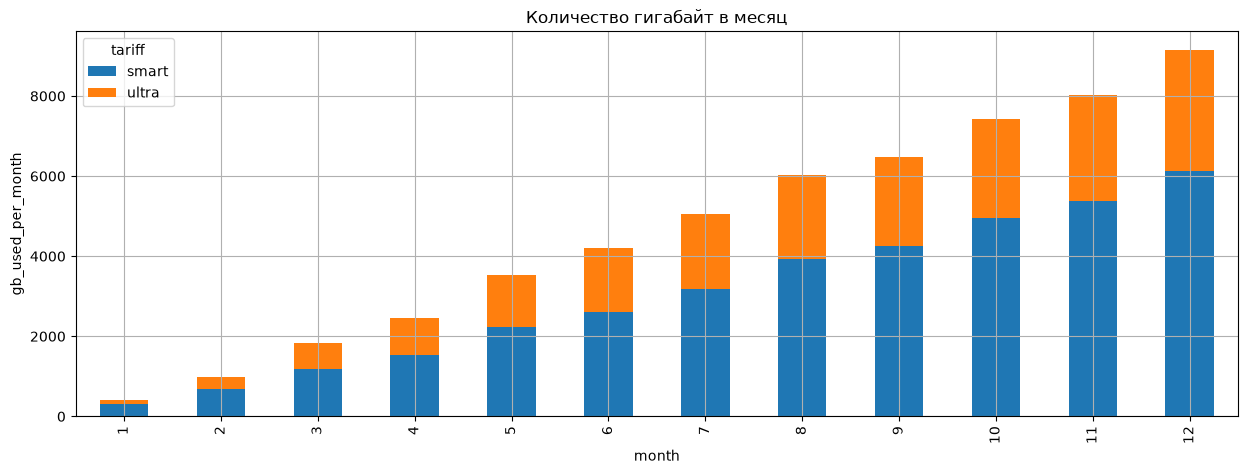

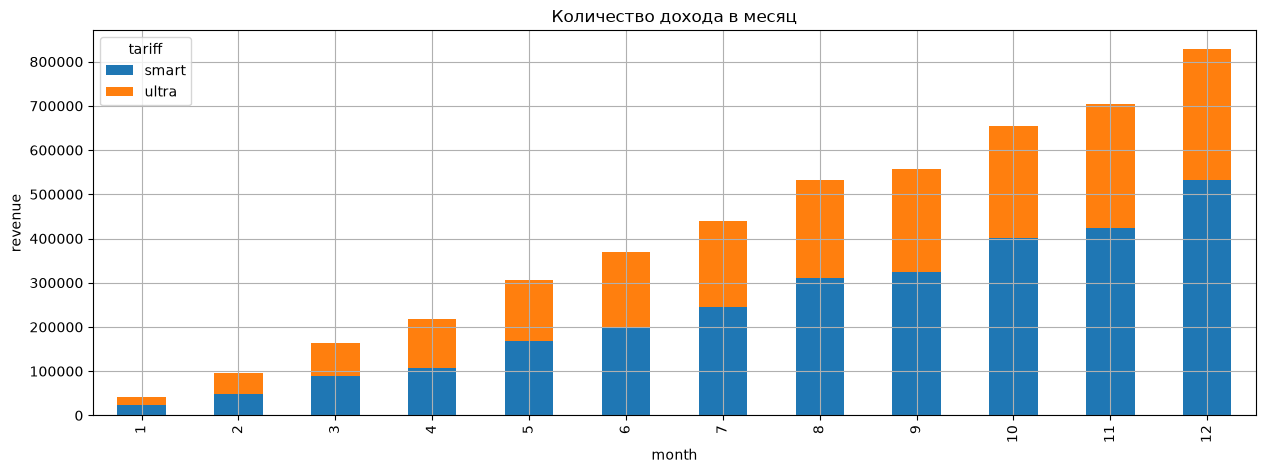

In [26]:
display(user_month.pivot_table('user_id', 'month', 'tariff', aggfunc='count'))

for parameter in ['minutes_per_month', 'used_msg_per_month', 'gb_used_per_month', 'revenue']:
  if parameter == 'minutes_per_month':
    par_name = 'минут'
  elif parameter == 'used_msg_per_month':
    par_name = 'сообщений'
  elif parameter == 'gb_used_per_month':
    par_name = 'гигабайт'
  elif parameter == 'revenue':
    par_name = 'дохода'

  fig, ax = plt.subplots(figsize=(15, 5))
  (
    user_month.pivot_table(
      index='month',
      columns='tariff',
      values=parameter,
      aggfunc='sum',
    )
    .plot(kind='bar', stacked=True, grid=True, ax=ax)
  )
  ax.set_title(f'Количество {par_name} в месяц')
  ax.set_xlabel('month')
  ax.set_ylabel(parameter)
  plt.show()

#### Вывод

На графиках и по таблице мы видим, что число пользователей росло каждый месяц, при этом на тарифе `smart` их всегда больше чем в два раза, чем на `ultra`. За счёт этого сумма минут, сообщений и трафика у `smart` выше. По доходу `ultra` сравнялась со `smart` в феврале, в апреле была чуть больше и немного отставала в июне. Дальше `smart` ушёл вперёд за счёт более быстрого прироста пользователей, а `ultra` прирастала малыми темпами.
